In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, requests
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential 

2022-09-05 18:54:08.853150: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-09-05 18:54:08.853184: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
api_key = '6d14aa23444d48f29f7cd6c14ee62a19'
symbol = 'BTC/USD'
interval = '5min'
order = 'asc'
start_date = '2022-08-01 00:00:00'
end_date = '2022-08-31 00:00:00'

api_url = f'https://api.twelvedata.com/time_series?symbol={symbol}&start_date={start_date}&end_date={end_date}&interval={interval}&order={order}&apikey={api_key}'

In [3]:
data = requests.get(api_url).json()
data_final = pd.DataFrame(data['values'])
data_final

,datetime,open,high,low,close
0,2022-08-13 15:25:00,24495.61914,24498.44922,24473.01953,24481.63086
1,2022-08-13 15:30:00,24484.46094,24504.49023,24459.66016,24459.66016
2,2022-08-13 15:35:00,24460.74023,24501.91992,24459.66016,24495.19922
3,2022-08-13 15:40:00,24494.64062,24518.59961,24487.22070,24516.00977
4,2022-08-13 15:45:00,24511.50000,24561.18945,24505.24023,24549.57031
...,...,...,...,...,...
4995,2022-08-30 23:40:00,19855.08008,19870.06055,19851.18945,19859.77930
4996,2022-08-30 23:45:00,19860.15039,19862.60938,19817.00977,19831.75000
4997,2022-08-30 23:50:00,19817.97070,19820.16016,19770.80078,19773.34961
4998,2022-08-30 23:55:00,19766.01953,19802.89062,19765.89062,19802.89062


In [4]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data_final['close'].values.reshape(-1,1))

In [5]:
data_final['close'].values

array(['24481.63086', '24459.66016', '24495.19922', ..., '19773.34961',
       '19802.89062', '19858.92969'], dtype=object)

In [6]:
time_intervals_to_train = 24
prediction_interval = 12

x_train, y_train = [],[]

In [7]:
for i in range(time_intervals_to_train, len(scaled_data)-prediction_interval):
    x_train.append(scaled_data[i - time_intervals_to_train:i,0])
    y_train.append(scaled_data[i+prediction_interval,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = np.reshape(x_train,(x_train.shape[0], x_train.shape[1],1))

In [8]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape = (x_train.shape[1],1), activation='relu'))
model.add(Dropout(0.4))
model.add(LSTM(64, return_sequences=True,activation='relu'))
model.add(Dropout(0.3))
model.add(LSTM(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation= 'sigmoid'))

2022-09-05 18:54:14.058440: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2022-09-05 18:54:14.058479: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2022-09-05 18:54:14.058518: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (codespaces-af4c92): /proc/driver/nvidia/version does not exist
2022-09-05 18:54:14.058783: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
model.compile(loss='mean_squared_error', optimizer='adam',metrics=['accuracy'])

In [10]:
model.fit(x_train,y_train,epochs=5 ,batch_size=64)

Epoch 1/5
78/78 [==============================] - 7s 55ms/step - loss: 0.0240 - accuracy: 4.0290e-04
Epoch 2/5
78/78 [==============================] - 4s 57ms/step - loss: 0.0021 - accuracy: 4.0290e-04
Epoch 3/5
78/78 [==============================] - 4s 57ms/step - loss: 0.0018 - accuracy: 4.0290e-04
Epoch 4/5
78/78 [==============================] - 4s 55ms/step - loss: 0.0018 - accuracy: 4.0290e-04
Epoch 5/5
78/78 [==============================] - 5s 59ms/step - loss: 0.0016 - accuracy: 4.0290e-04


In [11]:
start_date = '2022-08-31 00:00:00'
end_date = '2022-09-03 00:00:00'

test_api_url = f'https://api.twelvedata.com/time_series?symbol={symbol}&start_date={start_date}&end_date={end_date}&interval={interval}&order={order}&apikey={api_key}'

test_data = requests.get(test_api_url).json()
test_data_final = pd.DataFrame(test_data['values'])
test_data_final

,datetime,open,high,low,close
0,2022-08-31 00:00:00,19799.34961,19858.92969,19794.57031,19858.92969
1,2022-08-31 00:05:00,19842.83984,19906.14062,19842.83984,19885.28906
2,2022-08-31 00:10:00,19906.14062,19906.14062,19870.00000,19882.44922
3,2022-08-31 00:15:00,19875.02930,19893.42969,19875.02930,19879.00000
4,2022-08-31 00:20:00,19891.42969,19932.60938,19883.00977,19932.60938
...,...,...,...,...,...
860,2022-09-02 23:40:00,19948.21094,19948.21094,19935.51953,19937.91016
861,2022-09-02 23:45:00,19935.51953,19960.96094,19929.85938,19955.19922
862,2022-09-02 23:50:00,19960.96094,19960.96094,19926.05078,19926.05078
863,2022-09-02 23:55:00,19932.25977,19979.80078,19926.05078,19955.25000


In [12]:
bitcoin_prices = pd.to_numeric(test_data_final['close'], errors = 'coerce').values 

In [13]:
test_inputs = test_data_final['close'].values
test_inputs = test_inputs.reshape(-1,1)
model_inputs = scaler.fit_transform(test_inputs)

In [14]:
x_test = []

for x in range(time_intervals_to_train,len(model_inputs)):
    x_test.append(model_inputs[x - time_intervals_to_train:x,0])

x_test = np.array(x_test)
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [15]:
prediction_prices = model.predict(x_test)
prediction_prices = scaler.inverse_transform(prediction_prices)

27/27 [==============================] - 1s 11ms/step


In [16]:
prediction_prices

array([[19938.66 ],
       [19947.832],
       [19959.281],
       [19973.94 ],
       [19991.96 ],
       [20012.455],
       [20035.062],
       [20058.686],
       [20083.074],
       [20107.13 ],
       [20131.39 ],
       [20155.01 ],
       [20177.834],
       [20199.771],
       [20218.934],
       [20236.695],
       [20253.537],
       [20268.803],
       [20283.566],
       [20296.56 ],
       [20305.857],
       [20313.338],
       [20319.53 ],
       [20325.312],
       [20330.574],
       [20334.088],
       [20336.238],
       [20338.69 ],
       [20341.041],
       [20341.941],
       [20344.008],
       [20345.27 ],
       [20346.443],
       [20347.326],
       [20348.504],
       [20350.758],
       [20352.305],
       [20353.783],
       [20355.492],
       [20355.904],
       [20355.385],
       [20354.213],
       [20352.52 ],
       [20350.834],
       [20348.354],
       [20346.42 ],
       [20344.969],
       [20343.307],
       [20341.457],
       [20338.328],


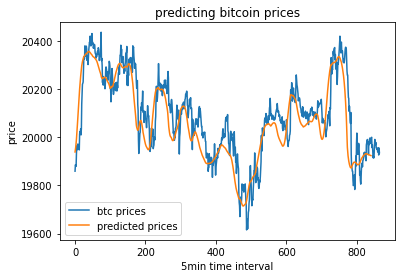

In [17]:
plt.plot(bitcoin_prices, label = 'btc prices')
plt.plot(prediction_prices, label = 'predicted prices')
plt.title('predicting bitcoin prices')
plt.xlabel('5min time interval')
plt.ylabel('price')
plt.legend()
plt.show()

In [18]:
last_data = model_inputs[len(model_inputs)+1 - time_intervals_to_train : len(model_inputs)+1,0]
last_data = np.array(last_data)
last_data = np.reshape(last_data,(1,last_data.shape[0],1))
last_data

array([[[0.46865019],
        [0.41646046],
        [0.43087372],
        [0.40447401],
        [0.36506617],
        [0.37477107],
        [0.36385871],
        [0.38329471],
        [0.42823971],
        [0.45788311],
        [0.4301664 ],
        [0.43158105],
        [0.44238624],
        [0.41557213],
        [0.41212124],
        [0.40743907],
        [0.41422893],
        [0.39579319],
        [0.39334256],
        [0.41442422],
        [0.37888166],
        [0.41448614],
        [0.39098957]]])

In [19]:
prediction = model.predict(last_data)
prediction = scaler.inverse_transform(prediction)
prediction

1/1 [==============================] - 0s 308ms/step


array([[19921.91]], dtype=float32)